# Graph-Structured Latent Covariance Learning for GMV Portfolio Optimization

**Pipeline:** $X_t \to A_t \to \text{GNN}_\theta \to H_t \to w^* \to \mathcal{L}$

($\Sigma_t = H_t H_t^\top + \epsilon I$ is implicit inside the GMV objective)

| Loss | Formula | Purpose |
|---|---|---|
| $\mathcal{L}_1$ | $w^{*\top} \hat{\Sigma}_t w^*$ | Pure variance minimization |
| $\mathcal{L}_2$ | $w^{*\top} \hat{\Sigma}_t w^* - \lambda \cdot w^{*\top} r_{t+1}$ | Mean-Variance (Markowitz) |

In [53]:
# !pip install torch torch-geometric cvxpy cvxpylayers yfinance scipy -q

In [71]:
import importlib
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

import models, dataset, losses
importlib.reload(models)
importlib.reload(dataset)
importlib.reload(losses)

from models  import GraphGMVModel
from dataset import PortfolioDataset, compute_adjacency
from losses  import loss_variance, loss_mean_variance

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)
print(f'Device: {device}')

Device: cpu


## 1. Configuration

In [72]:
# Fama-French 30 Industry Portfolios
INDUSTRIES = [
    'Food', 'Beer', 'Smoke', 'Games', 'Books', 'Hshld', 'Clths', 'Hlth',
    'Chems', 'Txtls', 'Cnstr', 'Steel', 'FabPr', 'ElcEq', 'Autos', 'Carry',
    'Mines', 'Coal',  'Oil',   'Util',  'Telcm', 'Servs', 'BusEq', 'Paper',
    'Trans', 'Whlsl', 'Rtail', 'Meals', 'Fin',   'Other'
]
TICKERS = INDUSTRIES   # 하위 셀 호환성 유지

SECTORS = {
    'Consumer'  : ['Food','Beer','Smoke','Hshld','Clths','Games','Books','Meals','Rtail','Whlsl'],
    'Healthcare': ['Hlth'],
    'Tech'      : ['BusEq','Telcm','Servs'],
    'Industrial': ['Chems','Txtls','Cnstr','Steel','FabPr','ElcEq','Autos','Carry','Paper','Trans'],
    'Energy'    : ['Oil','Coal','Mines'],
    'Util & Fin': ['Util','Fin'],
    'Other'     : ['Other'],
}
SECTOR_COLORS = {
    'Consumer'  : '#DD8452',
    'Healthcare': '#55A868',
    'Tech'      : '#4C72B0',
    'Industrial': '#8172B3',
    'Energy'    : '#C44E52',
    'Util & Fin': '#937860',
    'Other'     : '#bebebe',
}
ticker_to_sector = {t: s for s, ts in SECTORS.items() for t in ts}

CFG = {
    'industries'       : INDUSTRIES,

    # ── Data ──────────────────────────────────────────────────────────────
    'data_start'       : '2000-01-01',
    'data_end'         : '2025-12-31',

    # ── Outer walk-forward (expanding) ────────────────────────────────────
    # Fold 1: Train 2000~2013 / Val 2014~2015 / Test 2016~2017
    # Fold 2: Train 2000~2015 / Val 2016~2017 / Test 2018~2019
    # Fold 3: Train 2000~2017 / Val 2018~2019 / Test 2020~2021
    # Fold 4: Train 2000~2019 / Val 2020~2021 / Test 2022~2023
    # Fold 5: Train 2000~2021 / Val 2022~2023 / Test 2024~2025
    'init_train_year'  : 2013,   # Fold 1 train 마지막 연도
    'val_years'        : 2,      # Val 기간 (고정)
    'test_years'       : 2,      # Test 기간 (고정)
    'outer_step_years' : 2,      # train 확장 단위

    # ── Sample window (calendar 기준) ─────────────────────────────────────
    'lookback_years'   : 2,      # feature window (정확히 2 calendar years)
    'horizon_months'   : 1,      # r_next 보유 기간: 1개월 (월별 리밸런싱과 일치)
    # rebalancing: 매월 마지막 실제 거래일 (월말 거래일)
    'corr_threshold'   : 0.3,    # |Pearson| threshold for adjacency

    # ── Model ─────────────────────────────────────────────────────────────
    'n_features'       : 7,
    'd_hidden'         : 32,
    'd_latent'         : 16,
    'epsilon'          : 1e-4,

    # ── Training ──────────────────────────────────────────────────────────
    'lr'               : 1e-3,
    'n_epochs'         : 500,
    'patience'         : 50,
    'lam_mv'           : 1.0,    # L2 Mean-Variance: lambda (risk-return trade-off)
}

N = len(INDUSTRIES)
print(f'Universe: {N} industries')

Universe: 30 industries


## 2. Data Loading

In [73]:
import pandas as pd

prices  = pd.read_csv('csv/30_industry.csv', index_col=0, parse_dates=True)
prices  = prices[CFG['industries']].dropna()
returns = prices / 100

print(f'Returns shape: {returns.shape}')
print(f'Date range   : {returns.index[0].date()} ~ {returns.index[-1].date()}')
returns

Returns shape: (6539, 30)
Date range   : 2000-01-03 ~ 2025-12-31


,Food,Beer,Smoke,Games,Books,Hshld,Clths,Hlth,Chems,Txtls,...,Telcm,Servs,BusEq,Paper,Trans,Whlsl,Rtail,Meals,Fin,Other
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,-0.0227,-0.0116,0.0167,-0.0157,-0.0249,-0.0275,-0.0240,-0.0058,-0.0176,-0.0374,...,-0.0126,0.0247,0.0224,-0.0235,-0.0097,-0.0062,-0.0257,-0.0212,-0.0411,-0.0206
2000-01-04,-0.0227,-0.0111,0.0064,-0.0007,-0.0272,-0.0210,-0.0362,-0.0439,-0.0174,-0.0323,...,-0.0440,-0.0493,-0.0568,-0.0226,-0.0258,-0.0296,-0.0346,-0.0182,-0.0390,-0.0136
2000-01-05,0.0010,0.0133,-0.0041,-0.0040,-0.0220,-0.0142,0.0196,0.0232,0.0339,0.0137,...,0.0001,-0.0125,-0.0090,0.0216,0.0027,0.0216,-0.0097,0.0119,-0.0047,0.0021
2000-01-06,0.0116,0.0129,-0.0128,-0.0163,0.0023,0.0269,-0.0045,0.0268,0.0431,-0.0026,...,-0.0192,-0.0403,-0.0541,0.0317,0.0300,0.0339,-0.0013,-0.0073,0.0323,0.0026
2000-01-07,0.0123,0.0525,0.0275,0.0084,-0.0123,0.0540,0.0108,0.0761,0.0159,0.0167,...,0.0093,0.0346,0.0356,0.0170,0.0110,0.0285,0.0479,0.0150,0.0201,0.0060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-24,0.0046,0.0021,0.0037,0.0016,0.0028,0.0072,0.0171,0.0058,0.0046,0.0083,...,0.0064,0.0019,0.0018,0.0029,0.0030,0.0027,0.0052,0.0063,0.0053,0.0023
2025-12-26,-0.0008,-0.0010,-0.0021,0.0068,-0.0071,0.0011,0.0079,-0.0005,0.0036,0.0037,...,-0.0018,-0.0015,0.0033,0.0047,-0.0019,0.0014,0.0019,-0.0024,-0.0013,-0.0056
2025-12-29,0.0018,0.0019,0.0041,-0.0044,-0.0026,-0.0016,0.0000,-0.0026,-0.0037,-0.0025,...,0.0043,-0.0035,-0.0044,0.0019,-0.0030,-0.0025,-0.0016,-0.0059,-0.0071,0.0044


## 3. Dataset

In [74]:
import pandas as pd

returns_arr    = returns.values.astype(np.float32)
T              = len(returns_arr)
lookback_years = CFG['lookback_years']
horizon_months = CFG['horizon_months']

# ── 연도 기반 경계 ────────────────────────────────────────────────────────
def year_end_pos(year):
    return int(returns.index.searchsorted(pd.Timestamp(f'{year + 1}-01-01')))

# ── 월말 거래일 생성 (전체, 한 번만) ─────────────────────────────────────
try:
    all_rebal_dates = pd.DatetimeIndex(
        returns.index.to_series().resample('ME').last().dropna().values)
except Exception:
    all_rebal_dates = pd.DatetimeIndex(
        returns.index.to_series().resample('M').last().dropna().values)

# ── 유효 샘플 전체 생성 (조건: 2년 lookback 존재 & horizon 데이터 범위 내) ─
all_samples = []
for d in all_rebal_dates:
    lb_date = d - pd.DateOffset(years=lookback_years)
    h_date  = d + pd.DateOffset(months=horizon_months)
    if lb_date < returns.index[0]:
        continue
    lb_start = int(returns.index.searchsorted(lb_date))
    t        = int(returns.index.get_loc(d))
    h_end    = int(returns.index.searchsorted(h_date))
    if h_end <= T:
        all_samples.append((d, lb_start, t, h_end))

# ── Fold 데이터셋 생성 헬퍼 ──────────────────────────────────────────────
def make_fold_datasets(train_year, verbose=True):
    vy = train_year + CFG['val_years']
    ty = vy         + CFG['test_years']

    tr_end_pos = year_end_pos(train_year)
    vl_end_pos = year_end_pos(vy)
    ts_end_pos = min(year_end_pos(ty), T)

    tr_end_dt = pd.Timestamp(f'{train_year + 1}-01-01')
    vl_end_dt = pd.Timestamp(f'{vy + 1}-01-01')
    ts_end_dt = pd.Timestamp(f'{ty + 1}-01-01')

    s_tr = [(lb, t, h) for d, lb, t, h in all_samples
            if d  < tr_end_dt and h <= tr_end_pos]
    s_vl = [(lb, t, h) for d, lb, t, h in all_samples
            if tr_end_dt <= d < vl_end_dt and h <= vl_end_pos]
    s_ts = [(lb, t, h) for d, lb, t, h in all_samples
            if vl_end_dt <= d < ts_end_dt and h <= ts_end_pos]

    tr_ds = PortfolioDataset(returns_arr, s_tr, CFG['corr_threshold'])
    vl_ds = PortfolioDataset(returns_arr, s_vl, CFG['corr_threshold'])
    ts_ds = PortfolioDataset(returns_arr, s_ts, CFG['corr_threshold'])

    if verbose:
        data_start = returns.index[0].year   # 2000
        print(f'  Train:{len(tr_ds):4d} samples  {data_start}-01 ~ {train_year}-12')
        print(f'  Val  :{len(vl_ds):4d} samples  {train_year+1}-01 ~ {vy}-12')
        print(f'  Test :{len(ts_ds):4d} samples  {vy+1}-01 ~ {ty}-12')

    return tr_ds, vl_ds, ts_ds

# ── 전체 Fold 구조 출력 ───────────────────────────────────────────────────
fold_train_years = range(
    CFG['init_train_year'],
    CFG['init_train_year'] + 5 * CFG['outer_step_years'],
    CFG['outer_step_years'],
)
for fold_idx, train_year in enumerate(fold_train_years, 1):
    vy = train_year + CFG['val_years']
    ty = vy         + CFG['test_years']
    print(f'Fold {fold_idx}:  Train 2000~{train_year}  Val {train_year+1}~{vy}  Test {vy+1}~{ty}')
    make_fold_datasets(train_year, verbose=True)

# ── Fold 1 데이터셋 (시각화 / sanity check 용) ───────────────────────────
print(f'\nFold 1 datasets loaded for visualization/sanity check.')
train_ds, val_ds, test_ds = make_fold_datasets(CFG['init_train_year'], verbose=False)

Fold 1:  Train 2000~2013  Val 2014~2015  Test 2016~2017
  Train: 143 samples  2000-01 ~ 2013-12
  Val  :  23 samples  2014-01 ~ 2015-12
  Test :  23 samples  2016-01 ~ 2017-12
Fold 2:  Train 2000~2015  Val 2016~2017  Test 2018~2019
  Train: 167 samples  2000-01 ~ 2015-12
  Val  :  23 samples  2016-01 ~ 2017-12
  Test :  23 samples  2018-01 ~ 2019-12
Fold 3:  Train 2000~2017  Val 2018~2019  Test 2020~2021
  Train: 191 samples  2000-01 ~ 2017-12
  Val  :  23 samples  2018-01 ~ 2019-12
  Test :  23 samples  2020-01 ~ 2021-12
Fold 4:  Train 2000~2019  Val 2020~2021  Test 2022~2023
  Train: 215 samples  2000-01 ~ 2019-12
  Val  :  23 samples  2020-01 ~ 2021-12
  Test :  23 samples  2022-01 ~ 2023-12
Fold 5:  Train 2000~2021  Val 2022~2023  Test 2024~2025
  Train: 239 samples  2000-01 ~ 2021-12
  Val  :  23 samples  2022-01 ~ 2023-12
  Test :  24 samples  2024-01 ~ 2025-12

Fold 1 datasets loaded for visualization/sanity check.


Window : 2000-01-03 ~ 2001-12-31  (500 거래일)
Horizon: 2002-01-02 ~ 2002-01-31  (21 거래일)
Edges  : 249/435  (density=57.2%,  threshold=0.3)
Degree : mean=16.6,  min=1,  max=25


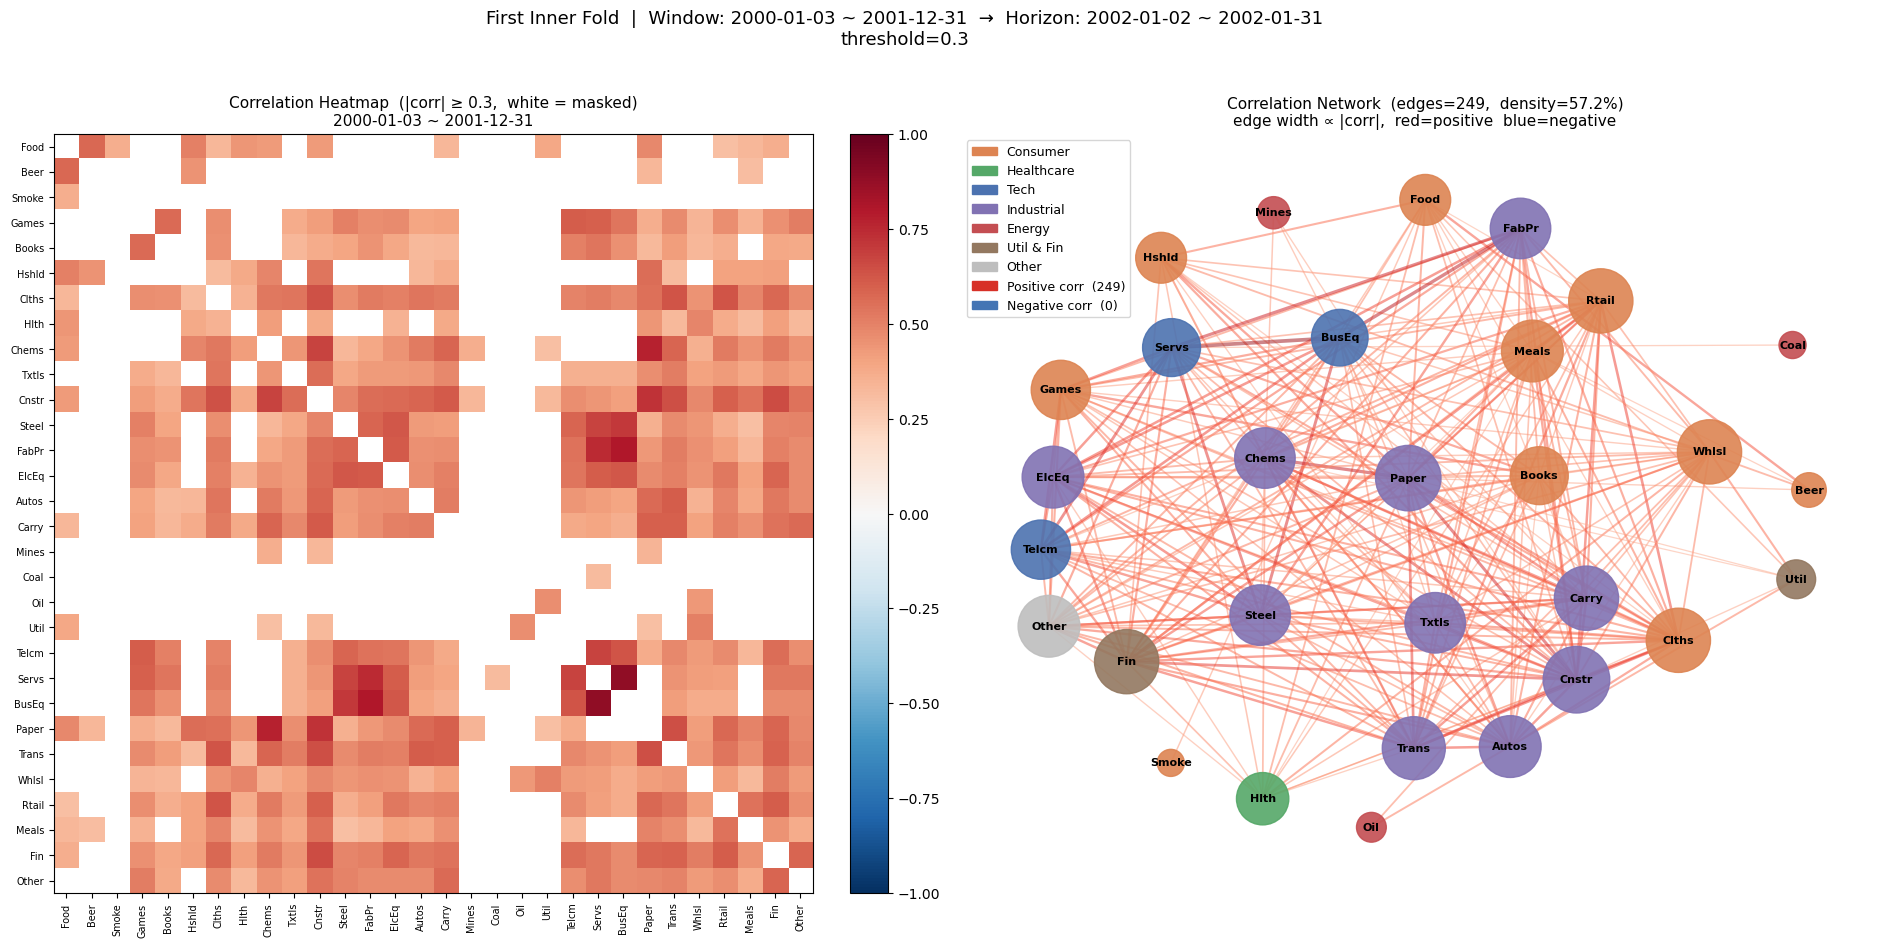


Positive edges: 249  |  Negative edges: 0


In [75]:
import networkx as nx

# ── 3-B. 첫 번째 inner fold 그래프 구조 시각화 ─────────────────────────────
# 첫 inner fold: lookback [2000.01 ~ 2001.12] → horizon [2002.01 ~ 2002.06]
lb_start   = 0                        # 데이터 시작 (2000-01-03)
t0         = year_end_pos(2001)       # 2001년 말 경계 (returns.index[t0] = 2002-01-02)

# h_end: returns.index[t0]는 거래일(2002-01-02)이므로, 달력 월초(2002-01-01)로
# 정규화한 뒤 6개월 더해야 searchsorted 결과가 2002-07-01 위치를 가리킴
#   → h_end0-1 = 2002-06-28 (6월 마지막 거래일)
fold_start = pd.Timestamp(f'{returns.index[t0].year}-{returns.index[t0].month:02d}-01')
h_end0     = int(returns.index.searchsorted(fold_start + pd.DateOffset(months=horizon_months)))
window0    = returns_arr[lb_start : t0]

# GCN 입력: |corr| 기반 thresholded adjacency
adj0  = compute_adjacency(window0, threshold=CFG['corr_threshold'])
# 시각화 전용: 부호 포함 원본 corr
corr0 = np.corrcoef(window0.T)

n_edges    = int((adj0 > 0).sum() // 2)
n_possible = N * (N - 1) // 2
density    = n_edges / n_possible
degree     = (adj0 > 0).sum(axis=1)

print(f'Window : {returns.index[lb_start].date()} ~ {returns.index[t0 - 1].date()}'
      f'  ({t0 - lb_start} 거래일)')
print(f'Horizon: {returns.index[t0].date()} ~ {returns.index[h_end0 - 1].date()}'
      f'  ({h_end0 - t0} 거래일)')
print(f'Edges  : {n_edges}/{n_possible}  (density={density:.1%},  threshold={CFG["corr_threshold"]})')
print(f'Degree : mean={degree.mean():.1f},  min={degree.min()},  max={degree.max()}')

# ── 그래프 구성 ─────────────────────────────────────────────────────────────
G = nx.Graph()
G.add_nodes_from(TICKERS)
for i in range(N):
    for j in range(i + 1, N):
        if adj0[i, j] > 0:
            G.add_edge(TICKERS[i], TICKERS[j],
                       weight=float(adj0[i, j]),          # |corr| → 두께
                       sign=float(np.sign(corr0[i, j])))  # 부호 → 색깔

pos_edges = [(u, v) for u, v, d in G.edges(data=True) if d['sign'] > 0]
neg_edges = [(u, v) for u, v, d in G.edges(data=True) if d['sign'] < 0]
pos_w     = [G[u][v]['weight'] for u, v in pos_edges]
neg_w     = [G[u][v]['weight'] for u, v in neg_edges]

node_colors = [SECTOR_COLORS.get(ticker_to_sector.get(t, 'Other'), 'gray') for t in TICKERS]
node_sizes  = [300 + degree[TICKERS.index(t)] * 80 for t in TICKERS]

for u, v, d in G.edges(data=True):
    d['inv_weight'] = 1.0 - d['weight']
pos = nx.spring_layout(G, weight='inv_weight', seed=42, k=2.5)

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# ── Left: adjacency heatmap (부호 포함, 발산형 컬러맵) ──────────────────────
ax = axes[0]
corr_masked = np.where(np.abs(corr0) >= CFG['corr_threshold'], corr0, np.nan)
np.fill_diagonal(corr_masked, np.nan)

cmap = plt.cm.RdBu_r
cmap.set_bad('white')
im = ax.imshow(corr_masked, cmap=cmap, vmin=-1, vmax=1)
ax.set_xticks(range(N)); ax.set_yticks(range(N))
ax.set_xticklabels(TICKERS, rotation=90, fontsize=7)
ax.set_yticklabels(TICKERS, fontsize=7)
ax.set_title(f'Correlation Heatmap  (|corr| ≥ {CFG["corr_threshold"]},  white = masked)\n'
             f'{returns.index[lb_start].date()} ~ {returns.index[t0 - 1].date()}', fontsize=11)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# ── Right: network graph ────────────────────────────────────────────────────
ax = axes[1]
nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                       node_size=node_sizes, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=ax)

if pos_edges:
    nx.draw_networkx_edges(G, pos, edgelist=pos_edges,
                           width=[w * 3 for w in pos_w],
                           edge_color=pos_w, edge_cmap=plt.cm.Reds,
                           edge_vmin=0, edge_vmax=1, alpha=0.5, ax=ax)
if neg_edges:
    nx.draw_networkx_edges(G, pos, edgelist=neg_edges,
                           width=[w * 3 for w in neg_w],
                           edge_color=neg_w, edge_cmap=plt.cm.Blues,
                           edge_vmin=0, edge_vmax=1, alpha=0.5, ax=ax)

patches  = [mpatches.Patch(color=c, label=s) for s, c in SECTOR_COLORS.items()]
patches += [mpatches.Patch(color='#d73027', label=f'Positive corr  ({len(pos_edges)})'),
            mpatches.Patch(color='#4575b4', label=f'Negative corr  ({len(neg_edges)})')]
ax.legend(handles=patches, fontsize=9, loc='upper left')
ax.set_title(f'Correlation Network  (edges={n_edges},  density={density:.1%})\n'
             f'edge width ∝ |corr|,  red=positive  blue=negative', fontsize=11)
ax.axis('off')

plt.suptitle(f'First Inner Fold  |  Window: {returns.index[lb_start].date()} ~ {returns.index[t0 - 1].date()}'
             f'  →  Horizon: {returns.index[t0].date()} ~ {returns.index[h_end0 - 1].date()}'
             f'\nthreshold={CFG["corr_threshold"]}', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('graph_structure_fold1.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nPositive edges: {len(pos_edges)}  |  Negative edges: {len(neg_edges)}')

## 4. Sanity Check

In [76]:
s        = train_ds[0]
m_tmp    = GraphGMVModel(N, CFG['n_features'], CFG['d_hidden'], CFG['d_latent'])
w_t, H_t = m_tmp(s['x'], s['edge_index'], s['edge_weight'])
S_t      = m_tmp.compute_sigma(H_t)
print(f'w_star: shape={tuple(w_t.shape)}, sum={w_t.sum().item():.4f}, min={w_t.min().item():.4f}')
print(f'Sigma : shape={tuple(S_t.shape)}, PSD={bool((torch.linalg.eigvalsh(S_t) > 0).all())}')
print(f'H     : shape={tuple(H_t.shape)}')

w_star: shape=(30,), sum=1.0000, min=0.0000
Sigma : shape=(30, 30), PSD=True
H     : shape=(30, 16)


In [77]:
# ── Gradient flow verification ──────────────────────────────────────────
# Check 1: w_star has grad_fn  (cvxpylayers attached to computation graph)
# Check 2: gradients reach GNN parameters  (end-to-end)

m_tmp.train()
s = train_ds[0]
x_v  = s['x'].requires_grad_(False)
ei_v = s['edge_index']
ew_v = s['edge_weight']
sig_v = s['sigma_sample']
r_v   = s['r_next']

w_star, H = m_tmp(x_v, ei_v, ew_v)

print(f'[1] w_star.grad_fn : {w_star.grad_fn}')       # should not be None
print(f'    H.grad_fn      : {H.grad_fn}')

loss = loss_variance(w_star, r_v, sig_v)
loss.backward()

grads = {name: (p.grad is not None) for name, p in m_tmp.named_parameters()}
all_have_grad = all(grads.values())
print(f'\n[2] Gradients reached all GNN parameters: {all_have_grad}')
for name, has_grad in grads.items():
    print(f'    {name:<40} grad={has_grad}')

[1] w_star.grad_fn : <ToCopyBackward0 object at 0x30dec2680>
    H.grad_fn      : <DivBackward0 object at 0x17f575f30>

[2] Gradients reached all GNN parameters: True
    gnn.conv1.bias                           grad=True
    gnn.conv1.lin.weight                     grad=True
    gnn.conv2.bias                           grad=True
    gnn.conv2.lin.weight                     grad=True
    gnn.bn1.weight                           grad=True
    gnn.bn1.bias                             grad=True


## 4-B. Embedding Diagnostics

In [78]:
# ── 4-B. Embedding Diagnostics ── (expanding loop 완성 후 trained model로 교체 예정)
# from sklearn.decomposition import PCA
# import matplotlib.patches as mpatches
#
# model_l1.eval()
# H_list = []
# with torch.no_grad():
#     for s in test_ds:
#         _, H = model_l1(s['x'], s['edge_index'], s['edge_weight'])
#         H_list.append(H.numpy())
#
# H_all  = np.stack(H_list, axis=0)
# H_mean = H_all.mean(axis=0)
#
# pca          = PCA(n_components=2)
# H_2d         = pca.fit_transform(H_mean)
# var_explained = pca.explained_variance_ratio_
# ...
pass

## 5. Training

In [79]:
from functools import partial

# ── Evaluation helpers ────────────────────────────────────────────────────
@torch.no_grad()
def get_weights(model, dataset, device):
    model.eval()
    ws, rs = [], []
    for s in dataset:
        w, _ = model(s['x'].to(device), s['edge_index'].to(device), s['edge_weight'].to(device))
        ws.append(w.cpu().numpy())
        rs.append(s['r_next'].numpy())
    return np.array(ws), np.array(rs)


def portfolio_metrics(w, r, freq=1, ann=12):
    """
    freq : horizon_months (1 = 월별 리밸런싱, 비겹침)
    ann  : 연환산 기준 (12개월)
    af   = ann / freq
    """
    pr  = (w * r).sum(axis=1)
    af  = ann / freq
    mu  = pr.mean() * af
    sig = pr.std()  * np.sqrt(af)
    cum = np.cumprod(1 + pr)
    pk  = np.maximum.accumulate(cum)
    mdd = ((cum - pk) / pk).min()
    return {
        'Ann. Return': mu, 'Ann. Vol': sig, 'Sharpe': mu / (sig + 1e-8),
        'Max DD': mdd,     'Calmar': mu / (-mdd + 1e-8),
        'cum_ret': cum,    'port_ret': pr,
    }


def ew_baseline(ds):
    return np.tile(1.0 / N, (len(ds), N)), np.array([s['r_next'].numpy() for s in ds])


def sample_gmv_baseline(ds):
    """Classic GMV: sample covariance, closed-form, long-only clipped."""
    ws, rs = [], []
    for s in ds:
        sig = s['sigma_sample'].numpy()
        try:
            inv = np.linalg.inv(sig + 1e-4 * np.eye(N))
            w   = inv @ np.ones(N)
            w   = np.clip(w, 0, None)
            w  /= w.sum() + 1e-8
        except np.linalg.LinAlgError:
            w = np.ones(N) / N
        ws.append(w)
        rs.append(s['r_next'].numpy())
    return np.array(ws), np.array(rs)


# ── Training helpers ──────────────────────────────────────────────────────
def run_epoch(model, dataset, optimizer, loss_fn, train, device):
    model.train(train)
    total = 0.0
    ctx   = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for s in dataset:
            x, ei, ew = s['x'].to(device), s['edge_index'].to(device), s['edge_weight'].to(device)
            sig, r    = s['sigma_sample'].to(device), s['r_next'].to(device)
            if train:
                optimizer.zero_grad()
            w_star, _ = model(x, ei, ew)
            loss      = loss_fn(w_star, r, sig)
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total += loss.item()
    return total / len(dataset)


def train_model(loss_fn, loss_name, train_ds, val_ds):
    model     = GraphGMVModel(N, CFG['n_features'], CFG['d_hidden'],
                              CFG['d_latent'], CFG['epsilon']).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=CFG['lr'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

    best_val, best_state, pat = float('inf'), None, 0
    tr_hist, val_hist = [], []

    for epoch in range(1, CFG['n_epochs'] + 1):
        tr  = run_epoch(model, train_ds, optimizer, loss_fn, True,  device)
        val = run_epoch(model, val_ds,   optimizer, loss_fn, False, device)
        scheduler.step(val)
        tr_hist.append(tr)
        val_hist.append(val)

        if val < best_val:
            best_val   = val
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            pat        = 0
        else:
            pat += 1

        if pat >= CFG['patience']:
            print(f'    [{loss_name}] Early stop @ epoch {epoch}')
            break
        if epoch % 10 == 0:
            print(f'    [{loss_name}] Ep {epoch:3d} | Train {tr:.6f} | Val {val:.6f}')

    model.load_state_dict(best_state)
    return model, tr_hist, val_hist

In [80]:
# ── Outer expanding walk-forward loop ────────────────────────────────────
# Fold 1: Train 2000~2013  Val 2014~2015  Test 2016~2017
# Fold 2: Train 2000~2015  Val 2016~2017  Test 2018~2019
# Fold 3: Train 2000~2017  Val 2018~2019  Test 2020~2021
# Fold 4: Train 2000~2019  Val 2020~2021  Test 2022~2023
# Fold 5: Train 2000~2021  Val 2022~2023  Test 2024~2025

fold_train_years = range(
    CFG['init_train_year'],
    CFG['init_train_year'] + 5 * CFG['outer_step_years'],
    CFG['outer_step_years'],
)   # [2013, 2015, 2017, 2019, 2021]

fold_results = {}   # fold_idx → {'EW', 'SampleGMV', 'Graph-L1', 'Graph-L2'}
fold_models  = {}   # fold_idx → {'l1': model, 'l2': model}

loss_mv = partial(loss_mean_variance, lam=CFG['lam_mv'])

for fold_idx, train_year in enumerate(fold_train_years, 1):
    vy = train_year + CFG['val_years']
    ty = vy         + CFG['test_years']

    print(f'\n{"="*60}')
    print(f'Fold {fold_idx}:  Train 2000~{train_year}  '
          f'Val {train_year+1}~{vy}  Test {vy+1}~{ty}')
    print(f'{"="*60}')

    tr_ds_f, vl_ds_f, ts_ds_f = make_fold_datasets(train_year)

    print(f'\n  [L1 - Variance]')
    m_l1_f, _, _ = train_model(loss_variance, f'F{fold_idx}-L1', tr_ds_f, vl_ds_f)

    print(f'\n  [L2 - MeanVar]')
    m_l2_f, _, _ = train_model(loss_mv,       f'F{fold_idx}-L2', tr_ds_f, vl_ds_f)

    # ── 평가 ────────────────────────────────────────────────────────────
    hm = CFG['horizon_months']
    w_l1_f, r_ts_f = get_weights(m_l1_f, ts_ds_f, device)
    w_l2_f, _      = get_weights(m_l2_f, ts_ds_f, device)
    w_ew_f,  r_ew  = ew_baseline(ts_ds_f)
    w_gmv_f, r_gmv = sample_gmv_baseline(ts_ds_f)

    fold_results[fold_idx] = {
        'train_year': train_year,
        'EW'        : portfolio_metrics(w_ew_f,  r_ew,   freq=hm, ann=12),
        'SampleGMV' : portfolio_metrics(w_gmv_f, r_gmv,  freq=hm, ann=12),
        'Graph-L1'  : portfolio_metrics(w_l1_f,  r_ts_f, freq=hm, ann=12),
        'Graph-L2'  : portfolio_metrics(w_l2_f,  r_ts_f, freq=hm, ann=12),
    }
    fold_models[fold_idx] = {'l1': m_l1_f, 'l2': m_l2_f}

    keys = ['Ann. Return', 'Ann. Vol', 'Sharpe', 'Max DD']
    hdr  = f"  {'Metric':<14}{'EW':>10}{'SampleGMV':>12}{'Graph-L1':>12}{'Graph-L2':>12}"
    print(f'\n{hdr}')
    print(f'  {"-"*(len(hdr)-2)}')
    for k in keys:
        r = fold_results[fold_idx]
        print(f"  {k:<14}{r['EW'][k]:>10.4f}{r['SampleGMV'][k]:>12.4f}"
              f"{r['Graph-L1'][k]:>12.4f}{r['Graph-L2'][k]:>12.4f}")

print(f'\n{"="*60}')
print('All folds complete.')


Fold 1:  Train 2000~2013  Val 2014~2015  Test 2016~2017
  Train: 143 samples  2000-01 ~ 2013-12
  Val  :  23 samples  2014-01 ~ 2015-12
  Test :  23 samples  2016-01 ~ 2017-12

  [L1 - Variance]
    [F1-L1] Ep  10 | Train 0.000161 | Val 0.000160
    [F1-L1] Ep  20 | Train 0.000120 | Val 0.000156
    [F1-L1] Ep  30 | Train 0.000115 | Val 0.000158
    [F1-L1] Ep  40 | Train 0.000112 | Val 0.000159
    [F1-L1] Ep  50 | Train 0.000111 | Val 0.000159
    [F1-L1] Early stop @ epoch 55

  [L2 - MeanVar]
    [F1-L2] Ep  10 | Train -0.018482 | Val 0.030626
    [F1-L2] Ep  20 | Train -0.025800 | Val 0.031555
    [F1-L2] Ep  30 | Train -0.029174 | Val 0.031627
    [F1-L2] Ep  40 | Train -0.031816 | Val 0.031129
    [F1-L2] Ep  50 | Train -0.032739 | Val 0.031408
    [F1-L2] Early stop @ epoch 52

  Metric                EW   SampleGMV    Graph-L1    Graph-L2
  ------------------------------------------------------------
  Ann. Return       0.2311      0.1675      0.3879      0.3839
  Ann. Vol   

## 6. Evaluation

In [81]:
strategies = ['EW', 'SampleGMV', 'Graph-L1', 'Graph-L2']
hm = CFG['horizon_months']
af = 12 / hm

# ── 전체 out-of-sample port_ret 연결 (fold 순서대로) ──────────────────────
full_pr = {s: np.concatenate([fold_results[f][s]['port_ret']
                               for f in sorted(fold_results)])
           for s in strategies}

# ── 전체 구간 가중치 재추출 ────────────────────────────────────────────────
full_w = {s: [] for s in strategies}
for fold_idx in sorted(fold_models):
    tr_y = fold_results[fold_idx]['train_year']
    _, _, ts_ds_f = make_fold_datasets(tr_y, verbose=False)
    w_l1_f, _ = get_weights(fold_models[fold_idx]['l1'], ts_ds_f, device)
    w_l2_f, _ = get_weights(fold_models[fold_idx]['l2'], ts_ds_f, device)
    full_w['Graph-L1'].append(w_l1_f)
    full_w['Graph-L2'].append(w_l2_f)
    full_w['EW'].append(ew_baseline(ts_ds_f)[0])
    full_w['SampleGMV'].append(sample_gmv_baseline(ts_ds_f)[0])
full_w = {s: np.concatenate(v) for s, v in full_w.items()}

# ── 전체 구간 성과 지표 ──────────────────────────────────────────────────
def full_period_metrics(pr):
    mu  = pr.mean() * af
    sig = pr.std()  * np.sqrt(af)
    cum = np.cumprod(1 + pr)
    pk  = np.maximum.accumulate(cum)
    mdd = ((cum - pk) / pk).min()
    return {'Ann. Return': mu, 'Ann. Vol': sig, 'Sharpe': mu / (sig + 1e-8),
            'Max DD': mdd, 'Calmar': mu / (-mdd + 1e-8), 'cum_ret': cum}

full_metrics = {s: full_period_metrics(full_pr[s]) for s in strategies}

# ── 테스트 구간 연도 계산 ─────────────────────────────────────────────────
ty_first = fold_results[min(fold_results)]['train_year']
ty_last  = fold_results[max(fold_results)]['train_year']
t_s = ty_first + CFG['val_years'] + 1           # 2016
t_e = ty_last  + CFG['val_years'] + CFG['test_years']  # 2025

# ── 결과 출력 ─────────────────────────────────────────────────────────────
keys = ['Ann. Return', 'Ann. Vol', 'Sharpe', 'Max DD', 'Calmar']
hdr  = f"{'Strategy':<14}" + ''.join(f'{k:>14}' for k in keys)
sep  = '=' * len(hdr)

print(f'Full Out-of-Sample Backtest  ({t_s}~{t_e})')
print(sep)
print(hdr)
print('-' * len(hdr))
for s in strategies:
    m = full_metrics[s]
    print(f"{s:<14}" + ''.join(f'{m[k]:>14.4f}' for k in keys))
print(sep)

Full Out-of-Sample Backtest  (2016~2025)
Strategy         Ann. Return      Ann. Vol        Sharpe        Max DD        Calmar
------------------------------------------------------------------------------------
EW                    0.1427        0.1699        0.8401       -0.2793        0.5110
SampleGMV             0.0947        0.1371        0.6910       -0.2544        0.3723
Graph-L1              0.2523        0.2324        1.0853       -0.3314        0.7611
Graph-L2              0.1606        0.2531        0.6346       -0.5827        0.2756


In [82]:
pass  # fold별 단독 평가 제거 → 전체 구간 집계 결과(위 셀)로 대체

## 7. Visualization

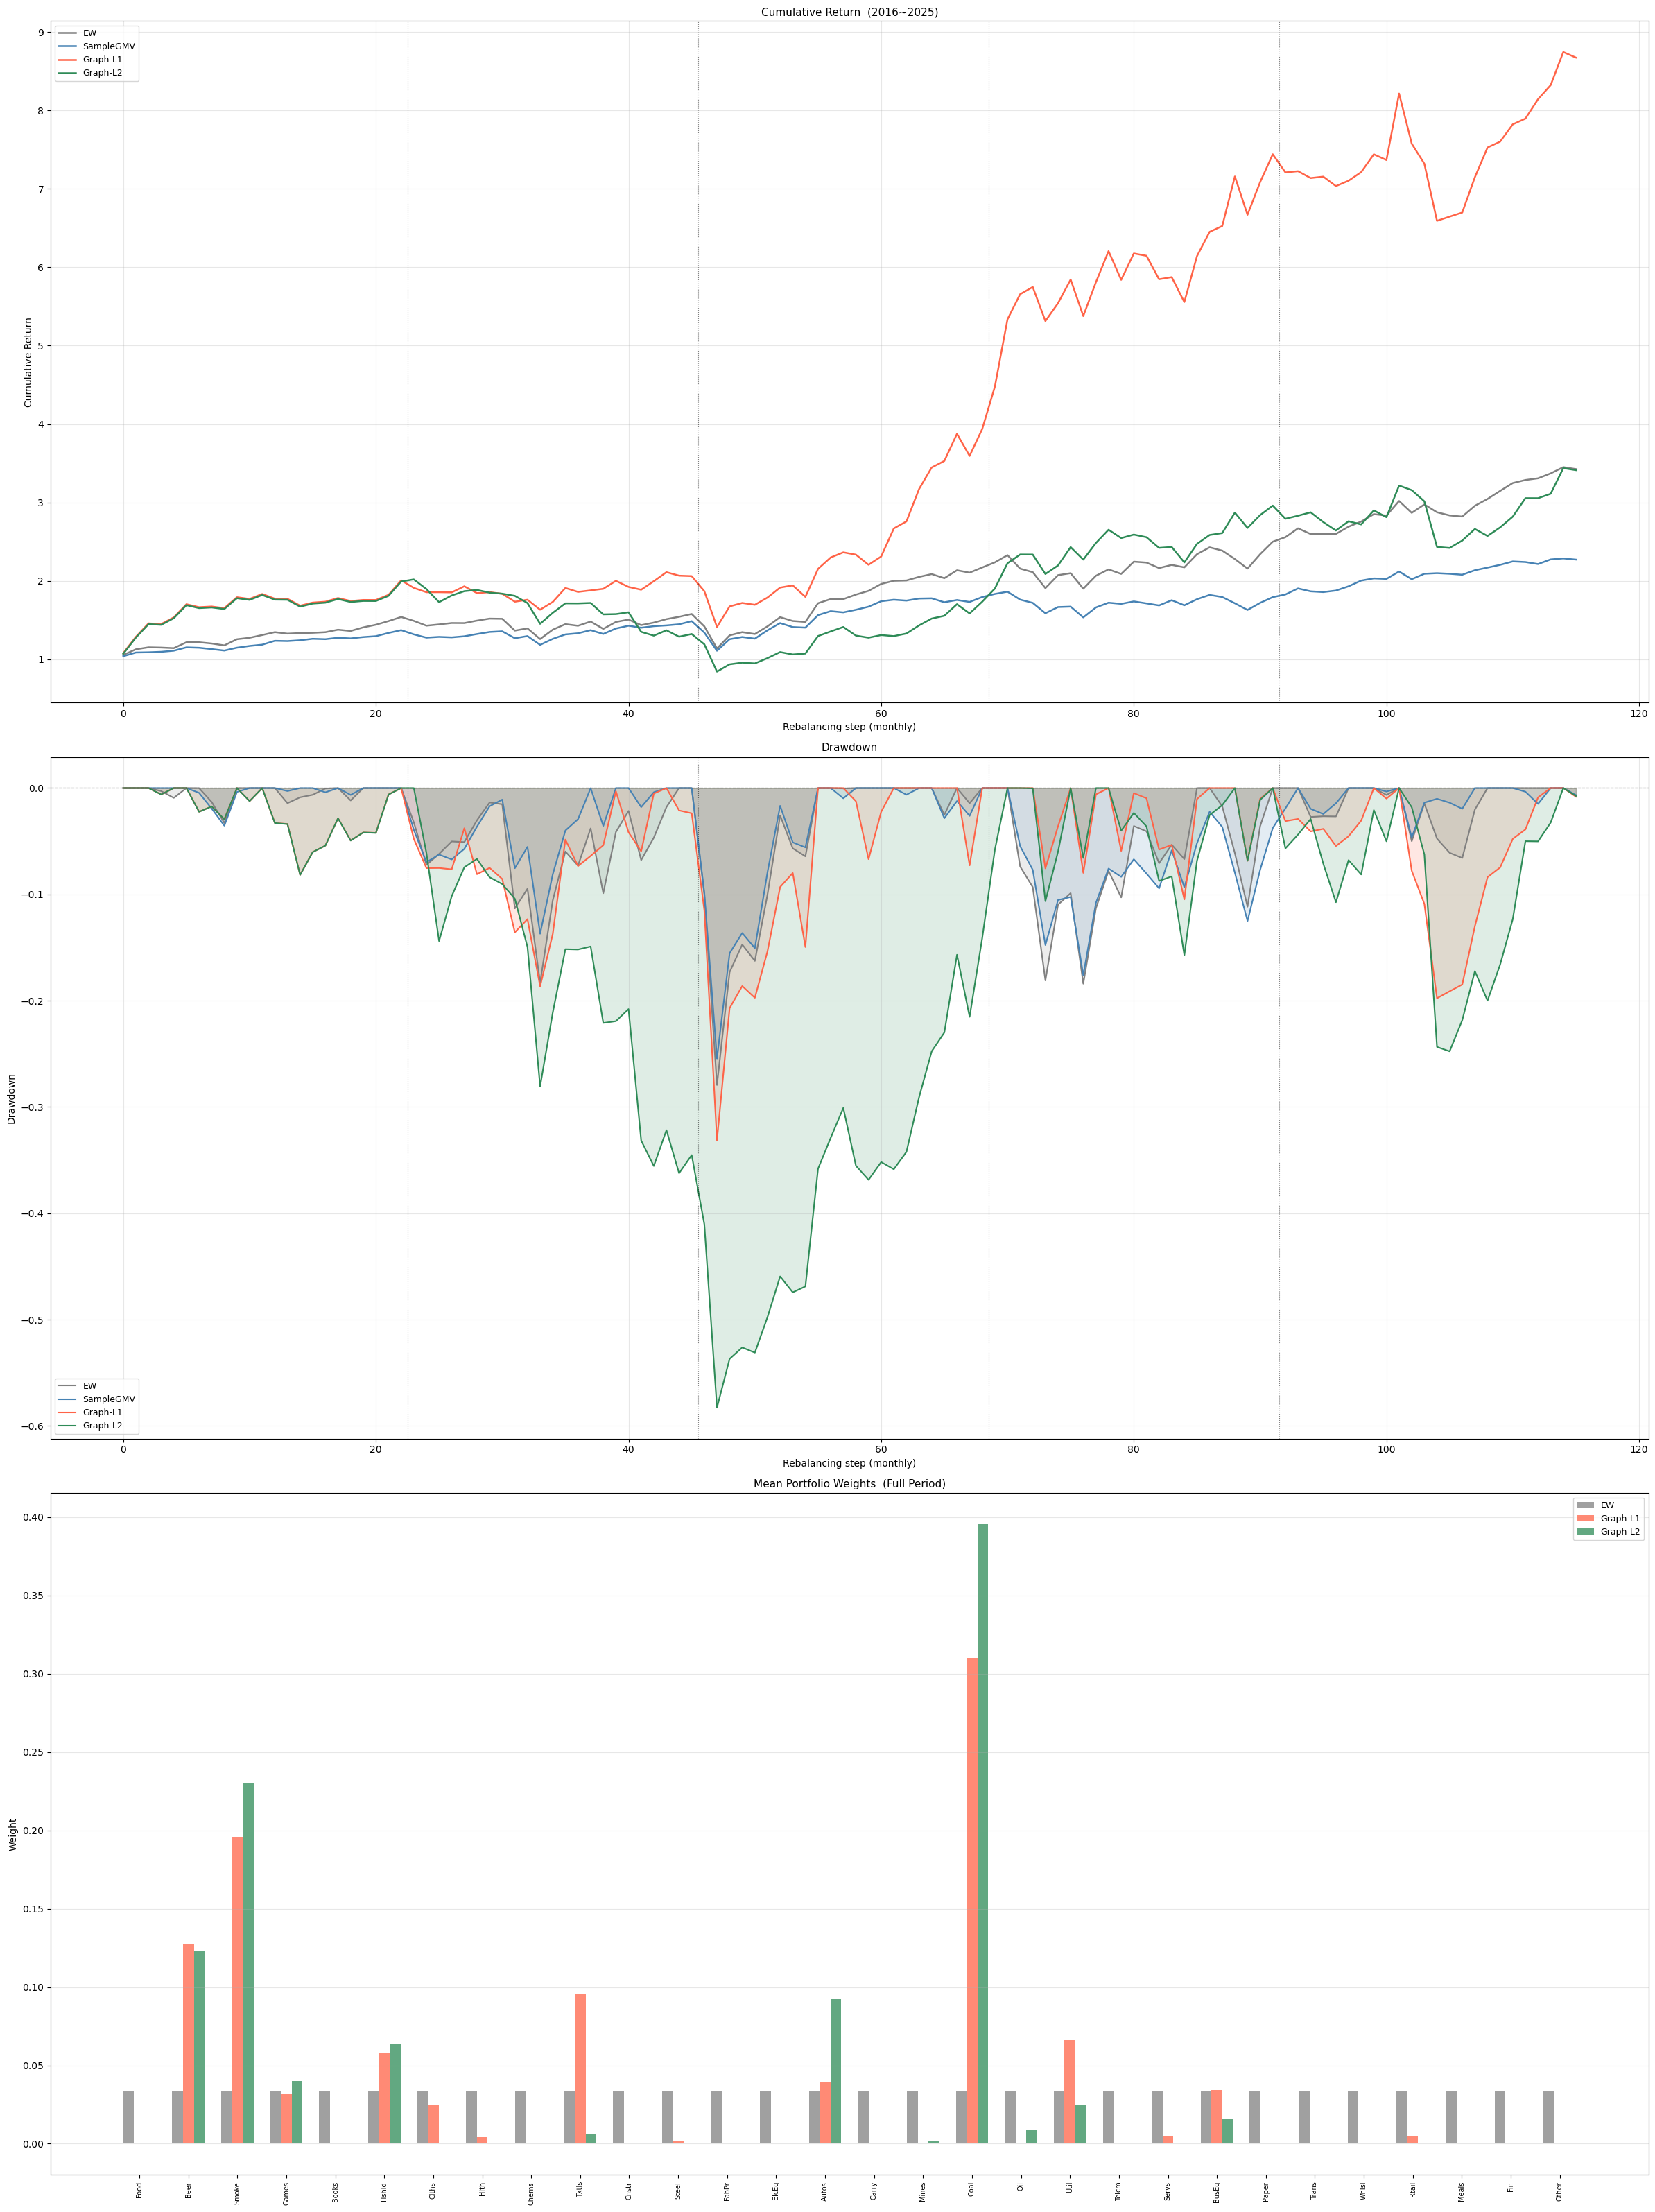

In [89]:
fig, axes = plt.subplots(3, 1, figsize=(24, 32))

strategies = ['EW', 'SampleGMV', 'Graph-L1', 'Graph-L2']
colors     = ['gray', 'steelblue', 'tomato', 'seagreen']

# ── Left: 전체 구간 누적 수익률 ──────────────────────────────────────────
ax = axes[0]
for s, c in zip(strategies, colors):
    ax.plot(full_metrics[s]['cum_ret'], label=s, color=c, linewidth=1.8)
# fold 경계 세로선
n_per_fold = len(fold_results[1]['EW']['port_ret'])
for i in range(1, len(fold_results)):
    ax.axvline(i * n_per_fold - 0.5, color='black', linewidth=0.8,
               linestyle=':', alpha=0.5)
ax.set_title(f'Cumulative Return  ({t_s}~{t_e})', fontsize=11)
ax.set_xlabel('Rebalancing step (monthly)')
ax.set_ylabel('Cumulative Return')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Middle: 드로우다운 ────────────────────────────────────────────────────
ax = axes[1]
for s, c in zip(strategies, colors):
    cum = full_metrics[s]['cum_ret']
    pk  = np.maximum.accumulate(cum)
    dd  = (cum - pk) / pk
    ax.fill_between(range(len(dd)), dd, 0, alpha=0.15, color=c)
    ax.plot(dd, label=s, color=c, linewidth=1.5)
for i in range(1, len(fold_results)):
    ax.axvline(i * n_per_fold - 0.5, color='black', linewidth=0.8,
               linestyle=':', alpha=0.5)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Drawdown', fontsize=11)
ax.set_xlabel('Rebalancing step (monthly)')
ax.set_ylabel('Drawdown')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Right: 평균 포트폴리오 비중 ──────────────────────────────────────────
ax   = axes[2]
x    = np.arange(N)
bw   = 0.22
plot_strats = [('EW', 'gray'), ('Graph-L1', 'tomato'), ('Graph-L2', 'seagreen')]
for i, (s, c) in enumerate(plot_strats):
    ax.bar(x + (i - 1) * bw, full_w[s].mean(0), bw,
           label=s, color=c, alpha=0.75)
ax.set_title('Mean Portfolio Weights  (Full Period)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(TICKERS, rotation=90, fontsize=7)
ax.set_ylabel('Weight')
ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='y')

# plt.suptitle(f'Full Out-of-Sample Backtest  ({t_s}~{t_e})', fontsize=13)
plt.tight_layout()
plt.savefig('results_full_period.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Concentration Analysis

In [84]:
def hhi(w):         return (w ** 2).sum(axis=1).mean()
def effective_n(w): return 1.0 / hhi(w)

print(f'Portfolio concentration  (full out-of-sample  {t_s}~{t_e}):')
print(f"  {'Strategy':<14}  {'HHI':>7}  {'Eff-N':>7}")
print('  ' + '-' * 32)
for s in strategies:
    print(f'  {s:<14}  HHI={hhi(full_w[s]):.4f}  Eff-N={effective_n(full_w[s]):.2f}')

Portfolio concentration  (full out-of-sample  2016~2025):
  Strategy            HHI    Eff-N
  --------------------------------
  EW              HHI=0.0333  Eff-N=30.00
  SampleGMV       HHI=0.0718  Eff-N=13.94
  Graph-L1        HHI=0.4198  Eff-N=2.38
  Graph-L2        HHI=0.4518  Eff-N=2.21
